In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings
# ---------------------------------------------------------
# 1. 환경 및 한글 폰트 설정   - 환경설정은 수업시간에 했던거 그대로 복사해서 사용했습니다
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # Colab / Linux 환경용 나눔바른고딕 폰트 경로
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 폰트가 없으면 설치 시도
    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 폰트 적용
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # Windows / Mac 대응
        if os.name == 'nt':
            plt.rc('font', family='Malgun Gothic')
        else:
            plt.rc('font', family='AppleGothic')

    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

    print('✅ 환경 설정 및 한글 폰트 로드 완료')

setup_environment()
print('라이브러리 임포트 완료')


✅ 환경 설정 및 한글 폰트 로드 완료
라이브러리 임포트 완료


In [ ]:
def load_data(url):
    df = pd.read_csv(url, encoding='cp949')
    return df

In [ ]:
def preprocess_date(df, date_col='일시'):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    df = df.set_index(date_col)
    df = df.sort_index()
    df['Year']  = df.index.year
    df['Month'] = df.index.month

    def get_season(month: int):
        if month in [3, 4, 5]:   return '봄'
        elif month in [6, 7, 8]: return '여름'
        elif month in [9, 10, 11]: return '가을'
        else:                    return '겨울'

    df['Season'] = df['Month'].apply(get_season)
    return df

In [ ]:
def handle_missing(df):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
    return df

In [ ]:
def min_max_scale(df, columns):

    df = df.copy()
    for col in columns:
        col_min = df[col].min()
        col_max = df[col].max()
        df[col + '_scaled'] = (df[col] - col_min) / (col_max - col_min)
    return df

In [ ]:
def add_moving_average(df, col='평균기온', window=7):
    df = df.copy()
    ma_col = col + '_' + str(window) + 'd_MA'
    df[ma_col] = df[col].rolling(window=window, center=True).mean()
    return df

In [ ]:
def calc_seasonal_stats(df):
    season_order = ['봄', '여름', '가을', '겨울']
    stats = df.groupby('Season')['평균기온'].agg(평균='mean',최솟값='min',최댓값='max',표준편차='std')
    stats = stats.round(2)
    stats = stats.reindex(season_order)
    return stats

In [ ]:
def build_pivot_table(df):
    season_order = ['가을', '겨울', '봄', '여름']
    pivot = pd.pivot_table(df, values='평균기온',index='Year',columns='Season',aggfunc='mean')
    pivot = pivot[season_order]
    pivot = pivot.round(1)
    pivot.index.name = 'Year'
    pivot.columns.name = '계절'
    return pivot

In [ ]:
def plot_all(df: pd.DataFrame, pivot: pd.DataFrame):
    season_order = ['봄', '여름', '가을', '겨울']
# 일단 1번이랑 2번 같이 만ㄷ든거
    fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

#기온 시계열 뭐시기
    ax1 = axes1[0]
    ax1.plot(df.index, df['평균기온'],color='lightgray', linewidth=0.6, label='원본')
    ax1.plot(df.index, df['평균기온_7d_MA'],color='red', linewidth=1.8, label='7일 이동평균')
    ax1.set_title('기온 시계열 변동 및 추세', fontsize=13)
    ax1.set_xlabel('일시')
    ax1.legend(loc='lower left', fontsize=9)

# 계절별 기ㅏ온 분포
    ax2 = axes1[1]
    data_by_season = [df[df['Season'] == s]['평균기온'].dropna().values
        for s in season_order]
    bp = ax2.boxplot(data_by_season,labels=season_order,patch_artist=True,widths=0.8,medianprops=dict(color='black', linewidth=0.5))

    for patch in bp['boxes']:
        patch.set_facecolor('#4c8fad')

    ax2.set_title('계절별 기온 분포', fontsize=13)
    ax2.set_xlabel('계절')
    ax2.set_ylabel('평균기온')
    fig1.tight_layout()
    plt.show()

# 이제 3이랑 4번
    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

#정규화 시킨거
    ax3 = axes2[0]
    scaled = df['평균기온_scaled'].dropna()
    counts, bin_edges, _ = ax3.hist(scaled, bins=22,color='mediumseagreen',edgecolor='black',label='분포')
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    smooth_counts = np.convolve(counts, np.ones(3) / 3 , mode='same')
    ax3.plot(bin_centers, smooth_counts,color='darkgreen', linewidth=2, label='분포 추세선')

    ax3.set_ylabel('Count')
    ax3.set_xlabel('평균기온_scaled')
    ax3.set_title('정규화된 기온 데이터 분포 (Min-Max Scaled)', fontsize=13)
    ax3.legend()

# 히트맵
    ax4 = axes2[1]
    heat_data = pivot.values
    im = ax4.imshow(heat_data, cmap='RdBu_r', aspect='auto',vmin=np.nanmin(heat_data),vmax=np.nanmax(heat_data))

    for spine in ax4.spines.values():
        spine.set_visible(False)

    ax4.set_xticks(range(len(pivot.columns)))
    ax4.set_yticks(range(len(pivot.index)))
    ax4.set_yticklabels(pivot.index.tolist(),rotation =90,va='center')
    ax4.set_ylabel('Year')
    ax4.set_xticklabels(pivot.columns.tolist())
    ax4.set_title('연도별/계절별 기온 히트맵',   fontsize=13)

    for i in range(heat_data.shape[0]):
        for j in range(heat_data.shape[1]):
            val = heat_data[i, j]
            season = pivot.columns[j]

            if not np.isnan(val):
                ax4.text(j, i, f'{val:.1f}',ha='center', va='center',fontsize=8,color='white' if season in ['겨울', '여름'] else 'black')

    cbar = fig2.colorbar(im, ax=ax4)
    cbar.outline.set_edgecolor('white')
    fig2.tight_layout()
    plt.show()

In [ ]:
def export_to_excel(df_clean, seasonal_stats, pivot, filepath='weather_analysis_report.xlsx'):

    with pd.ExcelWriter(filepath) as writer:
        df_clean.to_excel(writer, sheet_name='전처리_데이터')
        seasonal_stats.to_excel(writer, sheet_name='계절별_통계')
        pivot.to_excel(writer, sheet_name='연도별_피벗테이블')

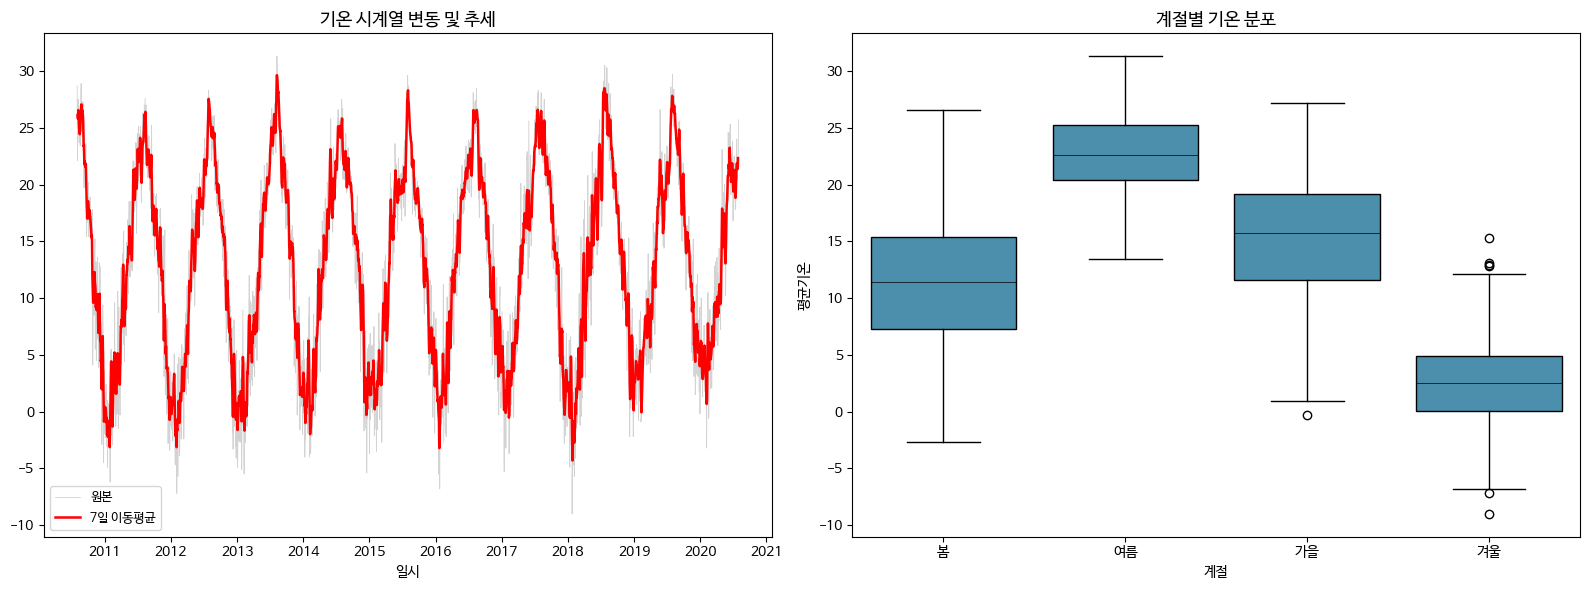

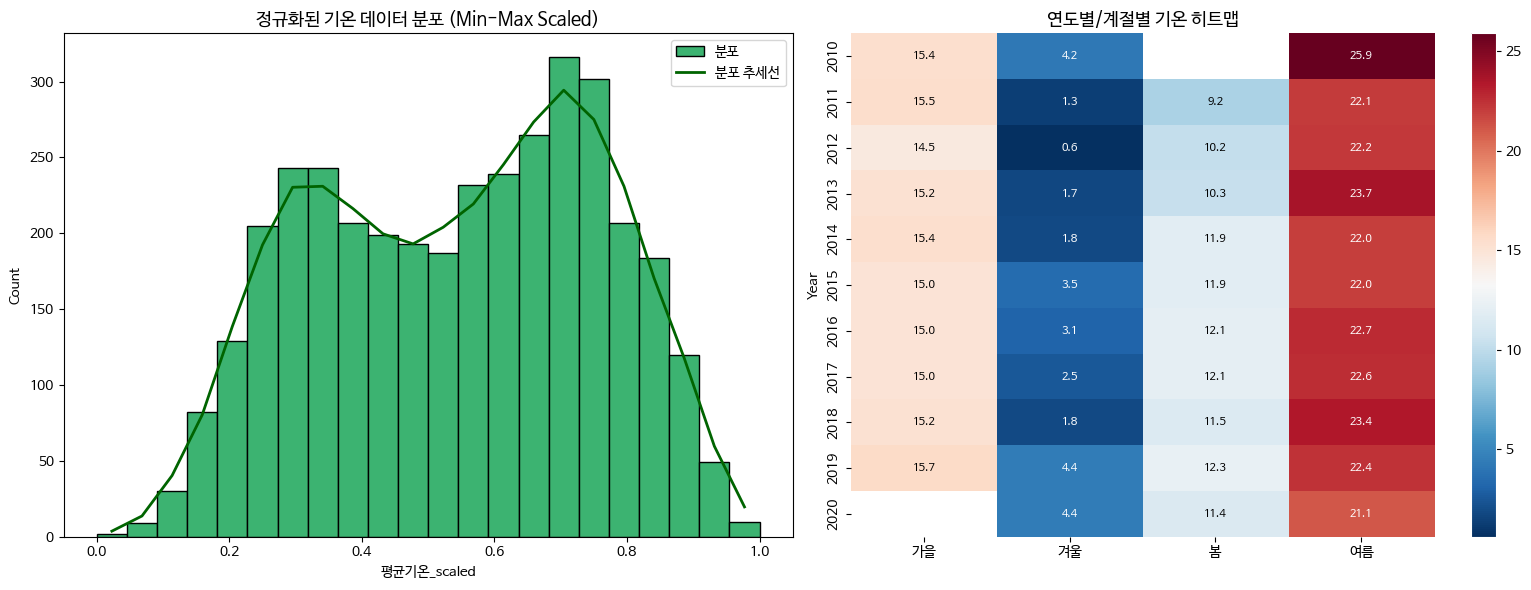

In [33]:
def main():
    URL = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'

    df = load_data(URL)
    df = preprocess_date(df, date_col='일시')
    df = handle_missing(df)
    numeric_cols_to_scale = ['평균기온', '최대풍속', '평균풍속', 'Year', 'Month']
    df = min_max_scale(df, numeric_cols_to_scale)
    df = add_moving_average(df)
    stats  = calc_seasonal_stats(df)
    pivot  = build_pivot_table(df)
    plot_all(df, pivot)
    export_to_excel(df, stats, pivot)
    return df, stats, pivot
df, stats, pivot = main()